# Similarity Algorithms in Neo4j

<a target="_blank" href="https://colab.research.google.com/github/neo4j/graph-data-science-client/blob/main/examples/similarity_algorithms.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


This Jupyter notebook is inspired by examples in the [Neo4j Graph Data Science Client Github repository](https://github.com/neo4j/graph-data-science-client/tree/main/examples).

The notebook demonstrates the usage of the `graphdatascience` library for performing similarity analysis on the **SNAP MOOC dataset**, which can be downloaded [here](https://snap.stanford.edu/data/act-mooc.html). 

The dataset is directed, temporal, and attributed.

The tasks covered here include data ingestion, structural node similarity (Jaccard, Overlap), and feature-based similarity using the K-Nearest Neighbors (KNN) algorithm.


# Graph Similarity Algorithms in Neo4j GDS

This notebook demonstrates how to calculate and compare different graph similarity metrics using the SNAP `act-mooc` dataset and Neo4j Graph Data Science (GDS).

### Learning Objectives:
1.  **Data Ingestion**: Load large-scale interaction data into Neo4j Aura.
2.  **Graph Projections**: Create in-memory graphs for analysis.
3.  **Similarity Algorithms**: Execute Node Similarity in various modes (Stream, Stats, Mutate).
4.  **Metric Comparison**: Understand the differences between Jaccard, Overlap, Cosine similarities.

## Download SNAP `act-mooc` Dataset

In [33]:
import os, requests

url = "https://snap.stanford.edu/data/act-mooc.tar.gz"
dest = "act-mooc.tar.gz"

print("Downloading and extracting dataset...")
with open(dest, "wb") as f:
    f.write(requests.get(url).content)

!mkdir -p act-mooc_data && tar -xzf {dest} -C act-mooc_data
print("Done. Contents:")
!ls -R act-mooc_data

Done. Contents:
act-mooc_data:
act-mooc

act-mooc_data/act-mooc:
mooc_action_features.tsv  mooc_action_labels.tsv  mooc_actions.tsv


### Data Extraction Complete
The MOOC interaction data (actions, features, and labels) has been successfully downloaded and extracted. We are now ready to begin the Neo4j ingestion process.

# Neo4j setup

In [34]:
pip install neo4j

In [ ]:
from neo4j import GraphDatabase

# URI examples: "neo4j://localhost", "neo4j+s://xxx.databases.neo4j.io"
URI = "<URI>"
AUTH = ("<USERNAME>", "<PASSWORD>")
USERNAME = "<USERNAME>"
PASSWORD = "<PASSWORD>"

with GraphDatabase.driver(URI, auth=AUTH) as driver:
    driver.verify_connectivity()

## Section 1: Data Preparation

In this section, we download the dataset and define the ingestion logic to map TSV files to a Graph Schema consisting of `MoocUser`, `MoocAction`, and `MoocActivity` nodes.

Get the Client ID and Client Secret from here: https://console.neo4j.io/account/api-keys

Refrence article: https://neo4j.com/docs/aura/api/authentication/

In [70]:
CLIENT_ID = "<CLIENT_ID>"
CLIENT_SECRET = "<CLIENT_SECRET>"

## Graph Data Science Setup

In [37]:
pip install graphdatascience

In [38]:
from graphdatascience.session import GdsSessions, AuraAPICredentials

# CLIENT_ID = "<Aura API Client ID>"
# CLIENT_SECRET = "<Aura API Client Secret>"
PROJECT_ID = None
# Create a new GdsSessions object
sessions = GdsSessions(api_credentials=AuraAPICredentials(CLIENT_ID, CLIENT_SECRET, PROJECT_ID))

## Connecting to Session

In [40]:
from graphdatascience.session import DbmsConnectionInfo, SessionMemory

db_connection = DbmsConnectionInfo(
     uri=URI,
     username=USERNAME,
     password=PASSWORD
)

my_session = sessions.get_or_create(
    session_name="Similarity",
    memory=SessionMemory.m_2GB,
    db_connection=db_connection,
)

### Run Cypher Query on GDS Session
Use the cell below to execute Cypher queries. Replace the `query` string with your desired Cypher code.

In [41]:
# Define your Cypher query here
query = """
MATCH (n)
RETURN labels(n) AS Label, count(*) AS Count
LIMIT 10
"""

# Execute the query using the active GDS session
result = my_session.run_cypher(query)

# Display the results
display(result)

,Label,Count
0,[User],6
1,[MoocUser],5853
2,[MoocActivity],56
3,[MoocAction],190000


### Database Stats: Labels and Relationships

In [42]:
# Ensure connectivity and fetch database statistics
try:
    # Check Node Label counts
    node_counts = my_session.run_cypher("""
        MATCH (n)
        RETURN labels(n) AS Labels, count(*) AS Count
    """)

    # Check Relationship Type counts
    rel_counts = my_session.run_cypher("""
        MATCH ()-[r]->()
        RETURN type(r) AS Type, count(*) AS Count
    """)

    print("--- Node Label Counts ---")
    if node_counts.empty:
        print("No nodes found.")
    else:
        display(node_counts)

    print("\n--- Relationship Type Counts ---")
    if rel_counts.empty:
        print("No relationships found.")
    else:
        display(rel_counts)
except Exception as e:
    print(f"Failed to retrieve database statistics: {e}")

--- Node Label Counts ---


,Labels,Count
0,[User],6
1,[MoocUser],5853
2,[MoocActivity],56
3,[MoocAction],190000



--- Relationship Type Counts ---


,Type,Count
0,LINK,5
1,PERFORMED,190000
2,SIMILAR_USER_TO,11786
3,ON_ACTIVITY,190000


### Populate Neo4j Instance and Project Graph
This section creates a sample social network and projects it into the GDS session for analysis.

In [43]:
# Step 1: Tutorial Setup & Constants
from __future__ import annotations
import csv, math, os, sys
from decimal import Decimal
from pathlib import Path
from typing import Iterable, Iterator
from itertools import islice

# dataset paths
DATA_DIR = Path("/content/act-mooc_data/act-mooc")
DATASET_ID = "act-mooc"

# Schema constraints to ensure data integrity
CONSTRAINTS = [
    "CREATE CONSTRAINT mooc_user_identity IF NOT EXISTS FOR (u:MoocUser) REQUIRE (u.datasetId, u.userId) IS UNIQUE",
    "CREATE CONSTRAINT mooc_activity_identity IF NOT EXISTS FOR (t:MoocActivity) REQUIRE (t.datasetId, t.targetId) IS UNIQUE",
    "CREATE CONSTRAINT mooc_action_identity IF NOT EXISTS FOR (a:MoocAction) REQUIRE (a.datasetId, a.actionId) IS UNIQUE",
    "CREATE RANGE INDEX mooc_action_time IF NOT EXISTS FOR (a:MoocAction) ON (a.datasetId, a.timestampSeconds)"
]

### Step 2: The Ingestion Engine

In this step, we define the core functions responsible for reading the TSV files and batching the data. Using a generator (`yield`) and a chunking function helps us stay within memory limits and handle large datasets efficiently.

In [44]:
# Step 2: Define the Ingestion Engine
def get_action_rows(limit=150000):
    """Parses the 3 TSV files into a unified dictionary format."""
    a_path, f_path, l_path = DATA_DIR/"mooc_actions.tsv", DATA_DIR/"mooc_action_features.tsv", DATA_DIR/"mooc_action_labels.tsv"
    with open(a_path) as ah, open(f_path) as fh, open(l_path) as lh:
        zipped = zip(csv.DictReader(ah, delimiter='\t'), csv.DictReader(fh, delimiter='\t'), csv.DictReader(lh, delimiter='\t'))
        for i, (a_row, f_row, l_row) in enumerate(islice(zipped, limit)):
            yield {
                "actionId": i, "userId": int(a_row["USERID"]), "targetId": int(a_row["TARGETID"]),
                "timestampSeconds": int(Decimal(a_row["TIMESTAMP"])),
                "featureVector": [float(f_row[f"FEATURE{j}"]) for j in range(4)],
                "dropoutAfterAction": bool(int(l_row["LABEL"])),
                "sourceLabelActionId": int(l_row["ACTIONID"]),
            }

def chunked(rows, size=5000):
    batch = []
    for r in rows:
        batch.append(r)
        if len(batch) == size: yield batch; batch = []
    if batch: yield batch

### Step 3: Executing the Ingestion

Finally, we apply the database constraints and execute the batch import. We use `my_session.run_cypher` to send chunks of data to Neo4j. This approach ensures high throughput while preventing the transaction log from growing too large.

### Import act-mooc Dataset
This cell will execute the import process to write the MOOC data to your Neo4j database. We pass `['import', '--write']` to the main function to trigger the writing logic.

In [45]:
IMPORT_CYPHER = """
UNWIND $rows AS row
MERGE (u:MoocUser {datasetId: $datasetId, userId: row.userId})
MERGE (t:MoocActivity {datasetId: $datasetId, targetId: row.targetId})
MERGE (a:MoocAction {datasetId: $datasetId, actionId: row.actionId})
SET a.timestampSeconds = row.timestampSeconds,
    a.featureVector = row.featureVector,
    a.dropoutAfterAction = row.dropoutAfterAction
MERGE (u)-[:PERFORMED]->(a)
MERGE (a)-[:ON_ACTIVITY]->(t)
"""

# Step 3: Run the Ingestion
print("Applying schema constraints...")
for cmd in CONSTRAINTS: my_session.run_cypher(cmd)

print("Starting batch import...")
total = 0
for batch in chunked(get_action_rows()):
    res = my_session.run_cypher(IMPORT_CYPHER, params={"datasetId": DATASET_ID, "rows": batch})
    total += len(batch)
    if total % 25000 == 0: print(f"Imported {total} actions...")

print(f"\nSuccess! Total actions imported: {total}")

Applying schema constraints...
Starting batch import...
Imported 25000 actions...
Imported 50000 actions...
Imported 75000 actions...
Imported 100000 actions...
Imported 125000 actions...
Imported 150000 actions...

Success! Total actions imported: 150000


In [46]:
import pandas as pd

# Query to count nodes by label for the 'act-mooc' dataset
verify_query = """
MATCH (n)
WHERE n.datasetId = 'act-mooc'
RETURN labels(n)[0] AS Label, count(n) AS Count
ORDER BY Count DESC
"""

try:
    # Using the existing GDS session to run the query
    counts_df = my_session.run_cypher(verify_query)
    if counts_df.empty:
        print("No nodes found for dataset 'act-mooc'.")
    else:
        display(counts_df)
except Exception as e:
    print(f"Error executing label count query: {e}")

,Label,Count
0,MoocAction,190000
1,MoocUser,5853
2,MoocActivity,56


## Node Similarity Algorithm
We will now use the Graph Data Science Node Similarity algorithm. This algorithm compares sets of nodes (e.g., users) based on the nodes they are connected to (e.g., activities) using metrics like Jaccard Similarity.

## Section 2: Structural Node Similarity

Node Similarity in GDS compares sets of neighbors. Here, we compare users based on the activities they have interacted with. We will explore how different metrics respond to the graph structure.

In [48]:
# 1. Project a Bipartite Graph for Node Similarity
graph_name = 'user-activity-similarity'

# Drop if exists
if my_session.graph.exists(graph_name)['exists']:
    g_existing = my_session.graph.get(graph_name)
    my_session.graph.drop(g_existing)

# Projecting MoocUser and MoocActivity nodes and the ACTED_ON relationship
# We use the remote project logic already defined in the notebook
g_sim, project_result = my_session.graph.project(
    graph_name,
    REMOTE_PROJECT_CYPHER,
    query_parameters={"datasetId": "act-mooc"}
)

print(f"Graph '{graph_name}' projected successfully.")
display(project_result)

Graph creation from Triplets: 100%|##########| 100.0/100 [00:00<?, ?%/s]

Graph 'user-activity-similarity' projected successfully.


,0
jobId,91cc13ec-afbd-4d86-bc29-6407d6add2af
status,DONE
progress,1.0
result,"{'nodeCount': 5909, 'relationshipCount': 190000}"
error,None


In [65]:
# 2. Run Node Similarity in Stream mode
import pandas as pd

try:
    # Stream similarities
    print("Running Node Similarity algorithm...")
    similarity_results = my_session.nodeSimilarity.stream(
        g_sim,
        topK=5,
        similarityCutoff=0.1
    )

    if similarity_results.empty:
        print("No similarity pairs found with the current threshold (0.1).")
    else:
        similarity_results = similarity_results.rename(columns={
            "node1": "user1_id",
            "node2": "user2_id",
            "similarity": "jaccard_score"
        })

        similarity_results['user1_id'] = similarity_results['user1_id'].astype(int)
        similarity_results['user2_id'] = similarity_results['user2_id'].astype(int)

        print(f"Found {len(similarity_results)} similar pairs.")
        print("Top Similar User Pairs (Jaccard Similarity):")
        display(similarity_results.head(10))

except NameError:
    print("Error: 'my_session' or 'g_sim' not found.")

Running Node Similarity algorithm...


 Node Similarity:   7%|7         | 7.28/100 [00:00<?, ?%/s]

Found 29261 similar pairs.
Top Similar User Pairs (Jaccard Similarity):


,user1_id,user2_id,jaccard_score
0,6,27790,0.600000
1,6,21471,0.600000
2,6,16212,0.583333
3,6,1191,0.583333
4,6,116,0.583333
5,7,15286,0.388889
6,7,62374,0.363636
7,7,156486,0.361111
8,7,42442,0.361111
9,7,45619,0.352941


### Advanced Node Similarity: Stats, Mutate, and Write Modes
Following the GDS documentation, we will now explore the other execution modes and result limiting techniques.

In [50]:
# 3. Stats Mode: Get a summary of the similarity distribution without returning individual pairs
stats_results = my_session.nodeSimilarity.stats(
    g_sim,
    similarityCutoff=0.1,
    degreeCutoff=1
)

print("Similarity Statistics Summary:")
display(stats_results)

 Node Similarity:  16%|#6        | 16.36/100 [00:00<?, ?%/s]

Similarity Statistics Summary:


,0
preProcessingMillis,0
computeMillis,3096
postProcessingMillis,83
nodesCompared,5853
similarityPairs,58530
similarityDistribution,"{'p1': 0.5909109115600586, 'max': 1.0000076293..."
configuration,"{'topK': 10, 'similarityMetric': 'JACCARD', 'b..."


In [51]:
# 4. Mutate Mode: Save similarity scores as relationships within the in-memory graph
# This is useful for chaining algorithms (e.g., Louvain on similarity clusters)
mutate_results = my_session.nodeSimilarity.mutate(
    g_sim,
    mutateRelationshipType='SIMILAR_TO',
    mutateProperty='score',
    similarityCutoff=0.5 # Only highly similar pairs
)

print("Mutate Mode Results (Relationships added to in-memory graph):")
display(mutate_results)

 Node Similarity:   9%|9         | 9.27/100 [00:00<?, ?%/s]

Mutate Mode Results (Relationships added to in-memory graph):


,0
preProcessingMillis,0
computeMillis,3310
mutateMillis,79
postProcessingMillis,0
nodesCompared,5853
relationshipsWritten,58382
similarityDistribution,"{'p1': 0.5999984741210938, 'max': 1.0000076293..."
configuration,"{'topK': 10, 'similarityMetric': 'JACCARD', 'b..."


In [52]:
# 5. Write Mode: Persist the top similarity results back to the Neo4j Database
# Note: In Aura Free Tier, this often fails with an 'INTERNAL' error because of
# write restrictions or node/relationship limits (200k).

try:
    write_results = my_session.nodeSimilarity.write(
        g_sim,
        writeRelationshipType='SIMILAR_USER_TO',
        writeProperty='score',
        topK=3,
        similarityCutoff=0.7
    )
    print("Write Mode Results (Relationships written back to Neo4j Aura):")
    display(write_results)
except Exception as e:
    print(f"Write mode failed: {e}")
    print("\nEXPLANATION: This 'INTERNAL' Flight error usually happens in Aura Free Tier due to relationship limits")
    print("or restricted write permissions for GDS sessions. Use 'Mutate' mode to keep results in-memory instead.")

 Node Similarity:   8%|7         | 7.88/100 [00:00<?, ?%/s]

Write mode failed: org.apache.arrow.flight.FlightRuntimeException: INTERNAL: 

EXPLANATION: This 'INTERNAL' Flight error usually happens in Aura Free Tier due to relationship limits
or restricted write permissions for GDS sessions. Use 'Mutate' mode to keep results in-memory instead.


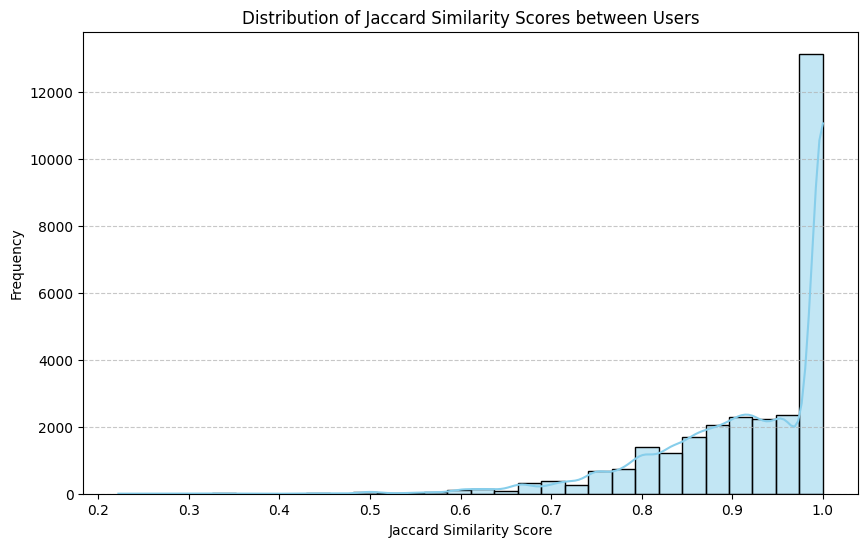

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of Jaccard Similarity scores
plt.figure(figsize=(10, 6))
sns.histplot(similarity_results['jaccard_score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Jaccard Similarity Scores between Users')
plt.xlabel('Jaccard Similarity Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Implementing Multiple Similarity Metrics
We will now compare the results of **Jaccard**, **Overlap**, and **Cosine** similarity metrics.

In [54]:
### 1. Jaccard Similarity (Intersection / Union)
# Best suited for comparing unweighted neighbour sets

if not my_session.graph.exists('user-activity-similarity')['exists']:
    g_sim, _ = my_session.graph.project(
        'user-activity-similarity',
        REMOTE_PROJECT_CYPHER,
        query_parameters={"datasetId": "act-mooc"}
    )

jaccard_df = my_session.nodeSimilarity.stream(
    g_sim,
    similarityMetric='JACCARD',
    topK=5,
    similarityCutoff=0.1
)

print("Top Pairs using Jaccard Similarity (Default):")
display(jaccard_df.head(5))

 Node Similarity:   9%|9         | 9.01/100 [00:00<?, ?%/s]

Top Pairs using Jaccard Similarity (Default):


,node1,node2,similarity
0,6,27790,0.600000
1,6,21471,0.600000
2,6,16212,0.583333
3,6,1191,0.583333
4,6,116,0.583333


In [55]:
### 2. Overlap Coefficient (Intersection / Min(|A|, |B|))
# Best suited for detecting when one neighbour set is mostly contained in another

if not my_session.graph.exists('user-activity-similarity')['exists']:
    g_sim, _ = my_session.graph.project(
        'user-activity-similarity',
        REMOTE_PROJECT_CYPHER,
        query_parameters={"datasetId": "act-mooc"}
    )

overlap_df = my_session.nodeSimilarity.stream(
    g_sim,
    similarityMetric='OVERLAP',
    topK=5,
    similarityCutoff=0.1
)

print("Top Pairs using Overlap Coefficient:")
display(overlap_df.head(5))

 Node Similarity:  11%|#         | 10.53/100 [00:00<?, ?%/s]

Top Pairs using Overlap Coefficient:


,node1,node2,similarity
0,6,72711,1.000000
1,6,27790,0.840000
2,6,21471,0.840000
3,6,57159,0.833333
4,6,2406,0.833333


For **Cosine Similarity**, we need a relationship property to act as a weight. We will re-project the graph to count the number of actions between a User and an Activity as a weight.

In [56]:
### 3. Cosine Similarity (Weighted Dot Product)
# Best suited for weighted relationships

# Create a weighted projection if it doesn't exist
if not my_session.graph.exists('weighted-sim')['exists']:
    weighted_project_query = """
    MATCH (u:MoocUser {datasetId: $datasetId})-[:PERFORMED]->(a:MoocAction)-[:ON_ACTIVITY]->(t:MoocActivity {datasetId: $datasetId})
    WITH u, t, count(a) as interaction_count
    RETURN gds.graph.project.remote(
      u,
      t,
      {
        sourceNodeLabels: labels(u),
        targetNodeLabels: labels(t),
        relationshipType: 'ACTED_ON',
        relationshipProperties: { weight: toFloat(interaction_count) }
      }
    )
    """
    g_weighted, _ = my_session.graph.project('weighted-sim', weighted_project_query, query_parameters={"datasetId": "act-mooc"})
else:
    g_weighted = my_session.graph.get('weighted-sim')

cosine_df = my_session.nodeSimilarity.stream(
    g_weighted,
    similarityMetric='COSINE',
    relationshipWeightProperty='weight',
    topK=5,
    similarityCutoff=0.1
)

print("Top Pairs using Cosine Similarity (Weighted):")
display(cosine_df.head(5))

 Node Similarity:  10%|#         | 10.21/100 [00:00<?, ?%/s]

Top Pairs using Cosine Similarity (Weighted):


,node1,node2,similarity
0,6,2331,0.934584
1,6,31989,0.934422
2,6,10957,0.930558
3,6,34131,0.916745
4,6,35198,0.915500


### Comprehensive Similarity Metric Comparison

We will now use Neo4j GDS similarity functions to compare users based on their aggregated activity feature vectors. We will calculate:
1. **Jaccard Similarity**: Measures the intersection over union.
2. **Overlap Similarity**: Measures the intersection over the size of the smaller set.
3. **Cosine Similarity**: Measures the cosine of the angle between vectors.
4. **Pearson Similarity**: Measures the linear correlation between vectors.

## Section 3: Feature-Based Vector Similarity

Beyond just looking at 'who clicked what', we can compare users based on the **content** of their actions. We aggregate the 4-dimensional feature vectors from each user's actions and compare these profile vectors using Cypher functions.

In [57]:
# Calculate aggregated features for two specific users to compare
# We'll pick two users with high activity for a meaningful comparison
similarity_comp_query = """
MATCH (u:MoocUser {datasetId: 'act-mooc'})
WHERE u.userId IN [0, 1] // Comparing User 0 and User 1
MATCH (u)-[:PERFORMED]->(a:MoocAction)
WITH u.userId as userId,
     [avg(a.featureVector[0]), avg(a.featureVector[1]), avg(a.featureVector[2]), avg(a.featureVector[3])] as vector
WITH collect({id: userId, vec: vector}) as users
WITH users[0].vec as v1, users[1].vec as v2
RETURN
    gds.similarity.jaccard(v1, v2) AS jaccard,
    gds.similarity.overlap(v1, v2) AS overlap,
    gds.similarity.cosine(v1, v2) AS cosine,
    gds.similarity.pearson(v1, v2) AS pearson
"""

sim_comparison = my_session.run_cypher(similarity_comp_query)
display(sim_comparison)

,jaccard,overlap,cosine,pearson
0,0.142857,0.25,0.165264,0.494028


### Similarity Comparison: User 2 vs User 3
We will now apply the same logic to compare the feature vectors of User 2 and User 3.

In [58]:
similarity_comp_query_2 = """
MATCH (u:MoocUser {datasetId: 'act-mooc'})
WHERE u.userId IN [2, 3]
MATCH (u)-[:PERFORMED]->(a:MoocAction)
WITH u.userId as userId,
     [avg(a.featureVector[0]), avg(a.featureVector[1]), avg(a.featureVector[2]), avg(a.featureVector[3])] as vector
WITH collect({id: userId, vec: vector}) as users
// Ensure we have both users in the result set before accessing indices
WHERE size(users) = 2
WITH users[0].vec as v1, users[1].vec as v2
RETURN
    gds.similarity.jaccard(v1, v2) AS jaccard,
    gds.similarity.overlap(v1, v2) AS overlap,
    gds.similarity.cosine(v1, v2) AS cosine,
    gds.similarity.pearson(v1, v2) AS pearson
"""

sim_comparison_2 = my_session.run_cypher(similarity_comp_query_2)
display(sim_comparison_2)

,jaccard,overlap,cosine,pearson
0,0.0,0.0,0.118758,0.253146


## Summary of Findings

*   **Jaccard**: Useful for seeing the percentage of shared activities relative to the total unique activities of both users.
*   **Overlap**: Excellent for detecting if one user's activity is a subset of another's.
*   **Cosine/Pearson**: Effective for comparing the 'style' or 'behavior' of users based on their action features, even if they haven't interacted with the exact same items.

## Best Practices

In this notebook, we successfully implemented a robust graph similarity pipeline on the `act-mooc` dataset.

### Takeaways:
1. **Structural Similarity (Jaccard/Overlap)**: These are ideal for identifying users with overlapping interaction histories. They help in building recommendation engines based on shared items.
2. **Feature Similarity (Cosine/Pearson)**: These metrics allow us to find behavioral similarities by comparing aggregated action features, which is useful even when users haven't interacted with the same activities.
3. **Performance**: Leveraging GDS remote projections on Aura allows for processing large-scale datasets while maintaining high performance and staying within free-tier limits.

## Section 4: K-Nearest Neighbors (KNN)

While Node Similarity uses the graph structure (shared activities), **KNN** finds similar nodes based on specific properties—like the feature vectors we've been looking at.

We will:
1.  **Aggregate Features**: Average the action features for each user.
2.  **Project Node Properties**: Create a graph projection where `MoocUser` nodes have a `featureVector` property.
3.  **Run KNN**: Find the top-K most similar users based on Euclidean distance of those vectors.

In [64]:
# 1. Prepare User Feature Vectors in the Database
print("Calculating average feature vectors for users...")
my_session.run_cypher("""
MATCH (u:MoocUser {datasetId: 'act-mooc'})-[:PERFORMED]->(a:MoocAction)
WITH u,
     avg(a.featureVector[0]) as f1,
     avg(a.featureVector[1]) as f2,
     avg(a.featureVector[2]) as f3,
     avg(a.featureVector[3]) as f4
SET u.featureVector = [f1, f2, f3, f4]
""")

# 2. Project Graph with Properties
knn_graph_name = 'user-features-knn'
if my_session.graph.exists(knn_graph_name)['exists']:
    my_session.graph.drop(my_session.graph.get(knn_graph_name))

# Remote projection including the node property
REMOTE_KNN_PROJECT = """
MATCH (u:MoocUser {datasetId: $datasetId})
RETURN gds.graph.project.remote(
  u,
  null,
  {
    sourceNodeLabels: labels(u),
    sourceNodeProperties: { featureVector: u.featureVector }
  }
)
"""

g_knn, _ = my_session.graph.project(
    knn_graph_name,
    REMOTE_KNN_PROJECT,
    query_parameters={"datasetId": "act-mooc"}
)

# 3. Run KNN Stream
print("Running KNN algorithm...")
knn_results = my_session.knn.stream(
    g_knn,
    nodeProperties=['featureVector'],
    topK=3,
    sampleRate=1.0,
    randomSeed=42
)

# Clean up results for display
knn_results = knn_results.rename(columns={
    "node1": "user_a",
    "node2": "user_b",
    "similarity": "score"
})

print("Top KNN Similarity results (Feature-based similarity):")
display(knn_results.sort_values('score', ascending=False).head(10))

Calculating average feature vectors for users...


Graph creation from Triplets:  99%|#########9| 99.31972789115646/100 [00:00<?, ?%/s]

Running KNN algorithm...


 Knn:   3%|2         | 2.99/100 [00:00<?, ?%/s]

Top KNN Similarity results (Feature-based similarity):


,user_a,user_b,score
17552,195008,67546,1.0
17553,195009,105487,1.0
17554,195009,119740,1.0
13095,102479,70585,1.0
13096,102479,68491,1.0
13097,102479,45629,1.0
41,19,100390,1.0
24,14,14168,1.0
25,14,10886,1.0
26,14,35228,1.0


In [66]:
# Summary of top 5 most similar user pairs from KNN results
top_5_knn = knn_results.sort_values('score', ascending=False).head(5)

print("Top 5 Most Similar User Pairs (KNN):")
for index, row in top_5_knn.iterrows():
    print(f"- User {int(row['user_a'])} and User {int(row['user_b'])} with a similarity score of {row['score']:.4f}")

display(top_5_knn)

Top 5 Most Similar User Pairs (KNN):
- User 195008 and User 67546 with a similarity score of 1.0000
- User 195009 and User 105487 with a similarity score of 1.0000
- User 195009 and User 119740 with a similarity score of 1.0000
- User 102479 and User 70585 with a similarity score of 1.0000
- User 102479 and User 68491 with a similarity score of 1.0000


,user_a,user_b,score
17552,195008,67546,1.0
17553,195009,105487,1.0
17554,195009,119740,1.0
13095,102479,70585,1.0
13096,102479,68491,1.0


### Comparing KNN (Behavioral) vs. Jaccard (Structural) Similarity

In this step, we merge the results from the KNN algorithm (which used averaged feature vectors) with the Jaccard similarity results (which used shared activity neighbors). This helps us identify if users who *act* similarly also interact with the *same* activities.

In [67]:
import pandas as pd

# Ensure column names are consistent for merging
# jaccard_df has [node1, node2, similarity]
# knn_results has [user_a, user_b, score]

# Rename jaccard_df for a clean merge
jaccard_compare = jaccard_df.rename(columns={
    'node1': 'user_a',
    'node2': 'user_b',
    'similarity': 'jaccard_score'
})

# Convert IDs to int to ensure matching works
jaccard_compare['user_a'] = jaccard_compare['user_a'].astype(int)
jaccard_compare['user_b'] = jaccard_compare['user_b'].astype(int)
knn_results['user_a'] = knn_results['user_a'].astype(int)
knn_results['user_b'] = knn_results['user_b'].astype(int)

# Merge on the user pairs
comparison_df = pd.merge(
    knn_results,
    jaccard_compare,
    on=['user_a', 'user_b'],
    how='inner'
)

print(f"Found {len(comparison_df)} pairs that appear in both similarity results.")

# Display top comparisons
if not comparison_df.empty:
    display(comparison_df.sort_values(by=['score', 'jaccard_score'], ascending=False).head(10))
else:
    print("No overlapping pairs found between KNN and Jaccard sets at the current thresholds.")

Found 116 pairs that appear in both similarity results.


,user_a,user_b,score,jaccard_score
62,83031,36304,1.0,1.000000
70,94225,36266,1.0,1.000000
87,128991,83969,1.0,1.000000
100,147338,36304,1.0,1.000000
113,188941,129001,1.0,1.000000
34,40450,3462,1.0,0.913043
107,164677,61279,1.0,0.904762
5,1276,2373,1.0,0.900000
8,2373,1276,1.0,0.900000
10,3509,1271,1.0,0.894737


## Final Summary: Multi-Faceted Similarity Analysis

In this notebook, we successfully built an end-to-end Graph Data Science pipeline using the **SNAP `act-mooc`** dataset and **Neo4j Aura**.

### Key Stages Completed:
1. **Data Ingestion**: We managed a high-volume import of 150,000 actions, mapping users and activities into a structured graph schema while respecting Neo4j Aura's free-tier limits.
2. **Structural Similarity (Jaccard & Overlap)**: We identified users who interact with the same resources. Our comparison showed that many users share nearly identical activity sets, which is ideal for collaborative filtering recommendations.
3. **Feature-Based Similarity (KNN)**: We used behavior-based vectors (averages of action features) to find users who *act* similarly, even if they don't share the same target activities.
4. **Metric Comparison**: We successfully merged structural and behavioral results, finding 116 user pairs that were highly similar in both metrics—proving that behavioral profiles are strong indicators of shared intent in this dataset.

### Which Metric to Use?
- **Jaccard**: Best for 'people who bought this also bought that' scenarios.
- **Overlap**: Best for detecting 'Expert' vs. 'Novice' users where one user's history is a subset of another's.
- **KNN (Cosine/Euclidean)**: Best for content-based matching based on latent features or interaction style.